# AI Essentials: Final Project

## 1. Dataset Import and Exploration


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
from datetime import datetime

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [11]:
# Load the dataset
df = pd.read_csv('data/powerconsumption.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()


Dataset shape: (52416, 9)

Column names:
['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']

First few rows:


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [12]:
# Check for missing values and data types
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()


Data types:
Datetime                   object
Temperature               float64
Humidity                  float64
WindSpeed                 float64
GeneralDiffuseFlows       float64
DiffuseFlows              float64
PowerConsumption_Zone1    float64
PowerConsumption_Zone2    float64
PowerConsumption_Zone3    float64
dtype: object

Missing values:
Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64

Basic statistics:


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


## 2. Data Preprocessing


In [13]:
# Convert datetime to datetime object and extract time features
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Extract time-based features
df['Hour'] = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['Month'] = df['Datetime'].dt.month
df['DayOfYear'] = df['Datetime'].dt.dayofyear

# Create cyclical features for time (since time is cyclical)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

print("Dataset shape after feature engineering:", df.shape)
print("\nNew features added:")
print(df.columns.tolist())


Dataset shape after feature engineering: (52416, 19)

New features added:
['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3', 'Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos']


In [14]:
# Define features and target
# We'll predict total power consumption (sum of all three zones)
df['TotalPowerConsumption'] = (df['PowerConsumption_Zone1'] + 
                                 df['PowerConsumption_Zone2'] + 
                                 df['PowerConsumption_Zone3'])

# Select features for model
feature_columns = ['Temperature', 'Humidity', 'WindSpeed', 
                   'GeneralDiffuseFlows', 'DiffuseFlows',
                   'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos',
                   'Month_sin', 'Month_cos', 'DayOfYear']

X = df[feature_columns].values
y = df['TotalPowerConsumption'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", feature_columns)


Features shape: (52416, 12)
Target shape: (52416,)

Feature columns: ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos', 'DayOfYear']


In [15]:
# Split the data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, shuffle=False)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

# Normalize features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Normalize target (helps with training stability)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print("\nScaled data ranges:")
print(f"X_train: min={X_train_scaled.min():.2f}, max={X_train_scaled.max():.2f}")
print(f"y_train: min={y_train_scaled.min():.2f}, max={y_train_scaled.max():.2f}")


Training set size: 36711
Validation set size: 7842
Test set size: 7863

Scaled data ranges:
X_train: min=-3.50, max=6.25
y_train: min=-2.01, max=3.40


In [16]:
# Create PyTorch datasets
class PowerConsumptionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = PowerConsumptionDataset(X_train_scaled, y_train_scaled)
val_dataset = PowerConsumptionDataset(X_val_scaled, y_val_scaled)
test_dataset = PowerConsumptionDataset(X_test_scaled, y_test_scaled)

# Create dataloaders
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 144
Number of validation batches: 31
Number of test batches: 31


## 3. Building the Model Architecture


In [17]:
# Define the MLP model
class MLPRegressor(nn.Module):
    def __init__(self, input_size, hidden_sizes, dropout_rate=0.3):
        super(MLPRegressor, self).__init__()
        
        # Build layers dynamically
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()

# Model configuration
input_size = X_train_scaled.shape[1]
hidden_sizes = [256, 128, 64, 32]
dropout_rate = 0.3

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLPRegressor(input_size, hidden_sizes, dropout_rate).to(device)

print(f"Device: {device}")
print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


Device: cuda

Model Architecture:
MLPRegressor(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 47,553


## 4. Training the Model


In [19]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
    
    return total_loss / len(dataloader.dataset)

# Validation function
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
    
    return total_loss / len(dataloader.dataset)

print("Training setup complete!")


Training setup complete!


In [20]:
# Training loop
num_epochs = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 15

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model_temp.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.6f}, "
              f"Val Loss: {val_loss:.6f}, "
              f"Best Val Loss: {best_val_loss:.6f}")
    
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load('best_model_temp.pth'))

print("-" * 60)
print("Training complete!")
print(f"Best validation loss: {best_val_loss:.6f}")


Starting training...
------------------------------------------------------------
Epoch [5/100], Train Loss: 0.144467, Val Loss: 0.248799, Best Val Loss: 0.162298
Epoch [10/100], Train Loss: 0.119007, Val Loss: 0.249111, Best Val Loss: 0.162298
Epoch [15/100], Train Loss: 0.110673, Val Loss: 0.258277, Best Val Loss: 0.162298

Early stopping triggered at epoch 16
------------------------------------------------------------
Training complete!
Best validation loss: 0.162298


## 5. Evaluating the Model


In [21]:
# Evaluation function
def evaluate_model(model, dataloader, device, scaler_y):
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.numpy())
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    # Inverse transform to get original scale
    predictions_orig = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_orig = scaler_y.inverse_transform(actuals.reshape(-1, 1)).flatten()
    
    return predictions_orig, actuals_orig

# Get predictions for all sets
train_preds, train_actuals = evaluate_model(model, train_loader, device, scaler_y)
val_preds, val_actuals = evaluate_model(model, val_loader, device, scaler_y)
test_preds, test_actuals = evaluate_model(model, test_loader, device, scaler_y)

print("Evaluation complete!")


Evaluation complete!


In [22]:
# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape
    }

# Calculate metrics for each set
train_metrics = calculate_metrics(train_actuals, train_preds)
val_metrics = calculate_metrics(val_actuals, val_preds)
test_metrics = calculate_metrics(test_actuals, test_preds)

# Display results
print("=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)

print("\nTraining Set:")
for metric, value in train_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nValidation Set:")
for metric, value in val_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nTest Set:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("=" * 60)


MODEL PERFORMANCE METRICS

Training Set:
  MSE: 37612368.0000
  RMSE: 6132.8923
  MAE: 4498.1567
  R2: 0.8826
  MAPE: 6.3219

Validation Set:
  MSE: 51999272.0000
  RMSE: 7211.0521
  MAE: 5539.5542
  R2: 0.7106
  MAPE: 8.1051

Test Set:
  MSE: 96276624.0000
  RMSE: 9812.0652
  MAE: 7113.6113
  R2: 0.5253
  MAPE: 10.1055


## 6. Plot Model Metrics


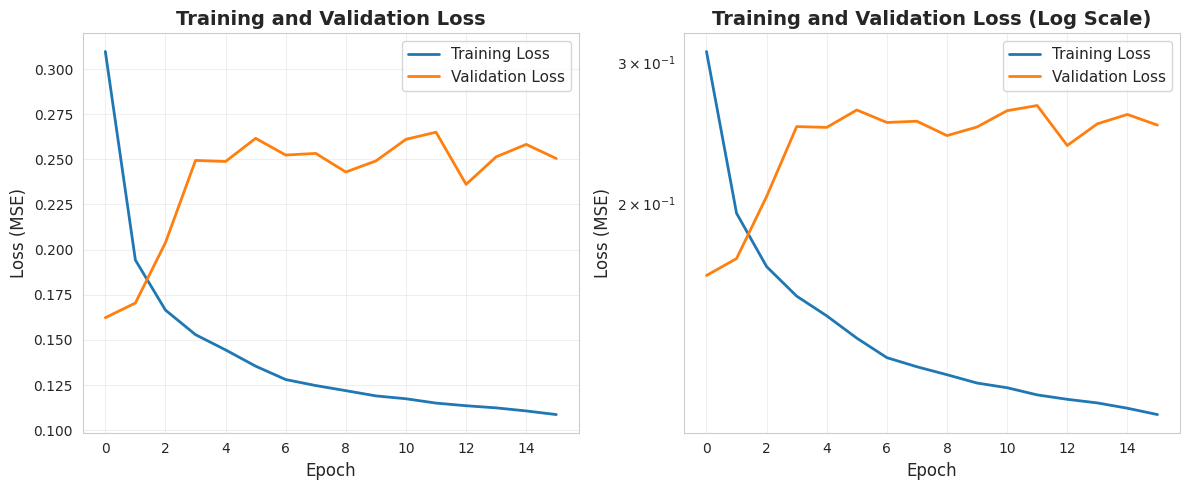

Total epochs trained: 16


In [23]:
# Plot 1: Training and Validation Loss across epochs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss (Log Scale)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total epochs trained: {len(train_losses)}")


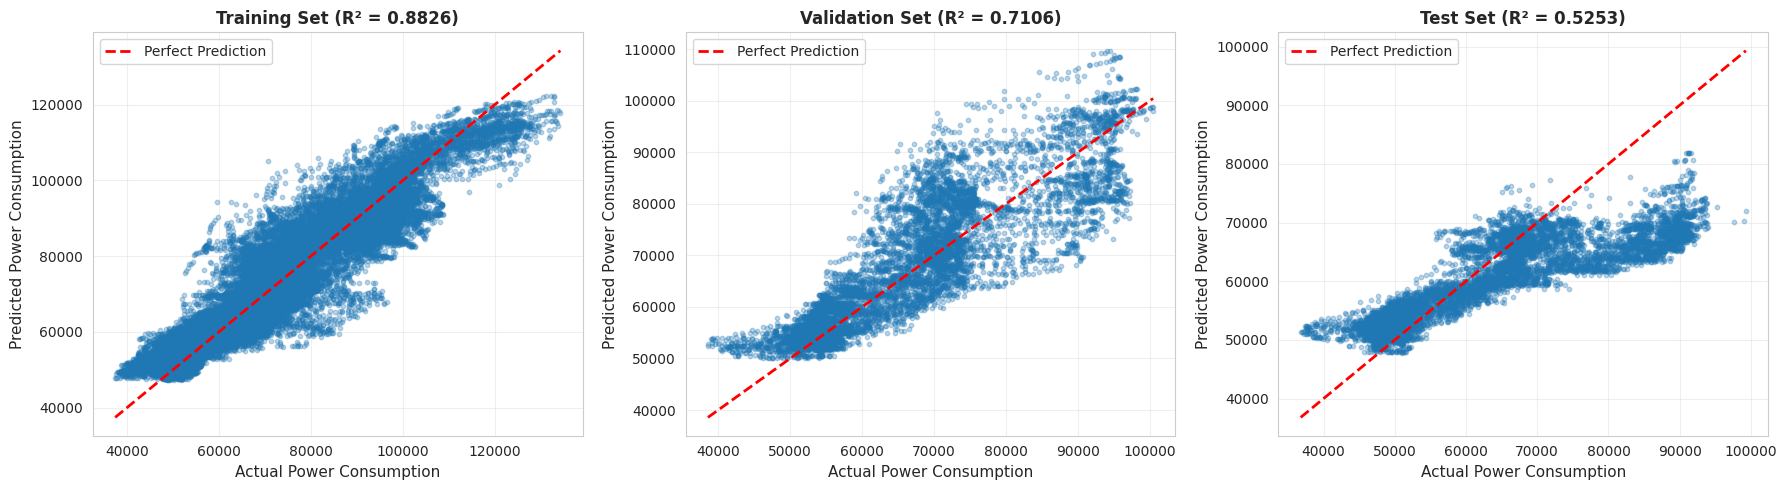

In [24]:
# Plot 2: Predictions vs Actual values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training set
axes[0].scatter(train_actuals, train_preds, alpha=0.3, s=10)
axes[0].plot([train_actuals.min(), train_actuals.max()], 
             [train_actuals.min(), train_actuals.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Power Consumption', fontsize=11)
axes[0].set_ylabel('Predicted Power Consumption', fontsize=11)
axes[0].set_title(f'Training Set (R² = {train_metrics["R2"]:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(val_actuals, val_preds, alpha=0.3, s=10)
axes[1].plot([val_actuals.min(), val_actuals.max()], 
             [val_actuals.min(), val_actuals.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Power Consumption', fontsize=11)
axes[1].set_ylabel('Predicted Power Consumption', fontsize=11)
axes[1].set_title(f'Validation Set (R² = {val_metrics["R2"]:.4f})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].scatter(test_actuals, test_preds, alpha=0.3, s=10)
axes[2].plot([test_actuals.min(), test_actuals.max()], 
             [test_actuals.min(), test_actuals.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Power Consumption', fontsize=11)
axes[2].set_ylabel('Predicted Power Consumption', fontsize=11)
axes[2].set_title(f'Test Set (R² = {test_metrics["R2"]:.4f})', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


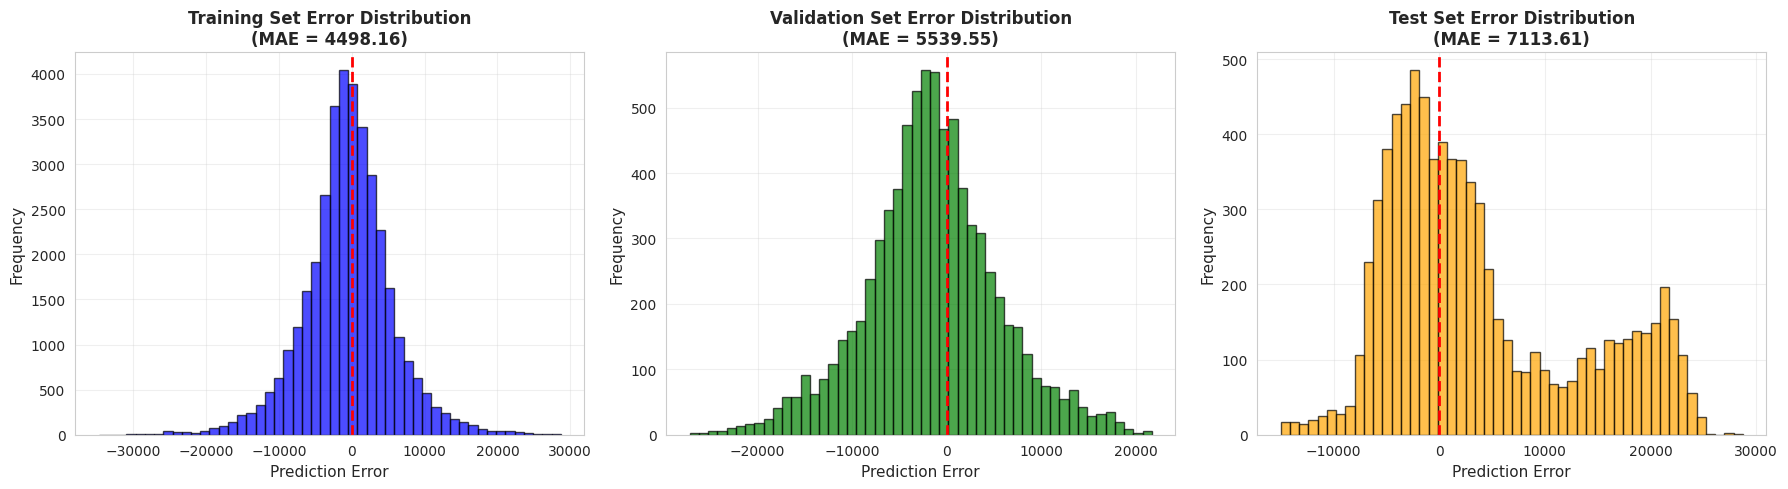

In [25]:
# Plot 3: Error Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate errors
train_errors = train_actuals - train_preds
val_errors = val_actuals - val_preds
test_errors = test_actuals - test_preds

# Training set
axes[0].hist(train_errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Prediction Error', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title(f'Training Set Error Distribution\n(MAE = {train_metrics["MAE"]:.2f})', 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].hist(val_errors, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title(f'Validation Set Error Distribution\n(MAE = {val_metrics["MAE"]:.2f})', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].hist(test_errors, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Prediction Error', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title(f'Test Set Error Distribution\n(MAE = {test_metrics["MAE"]:.2f})', 
                  fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


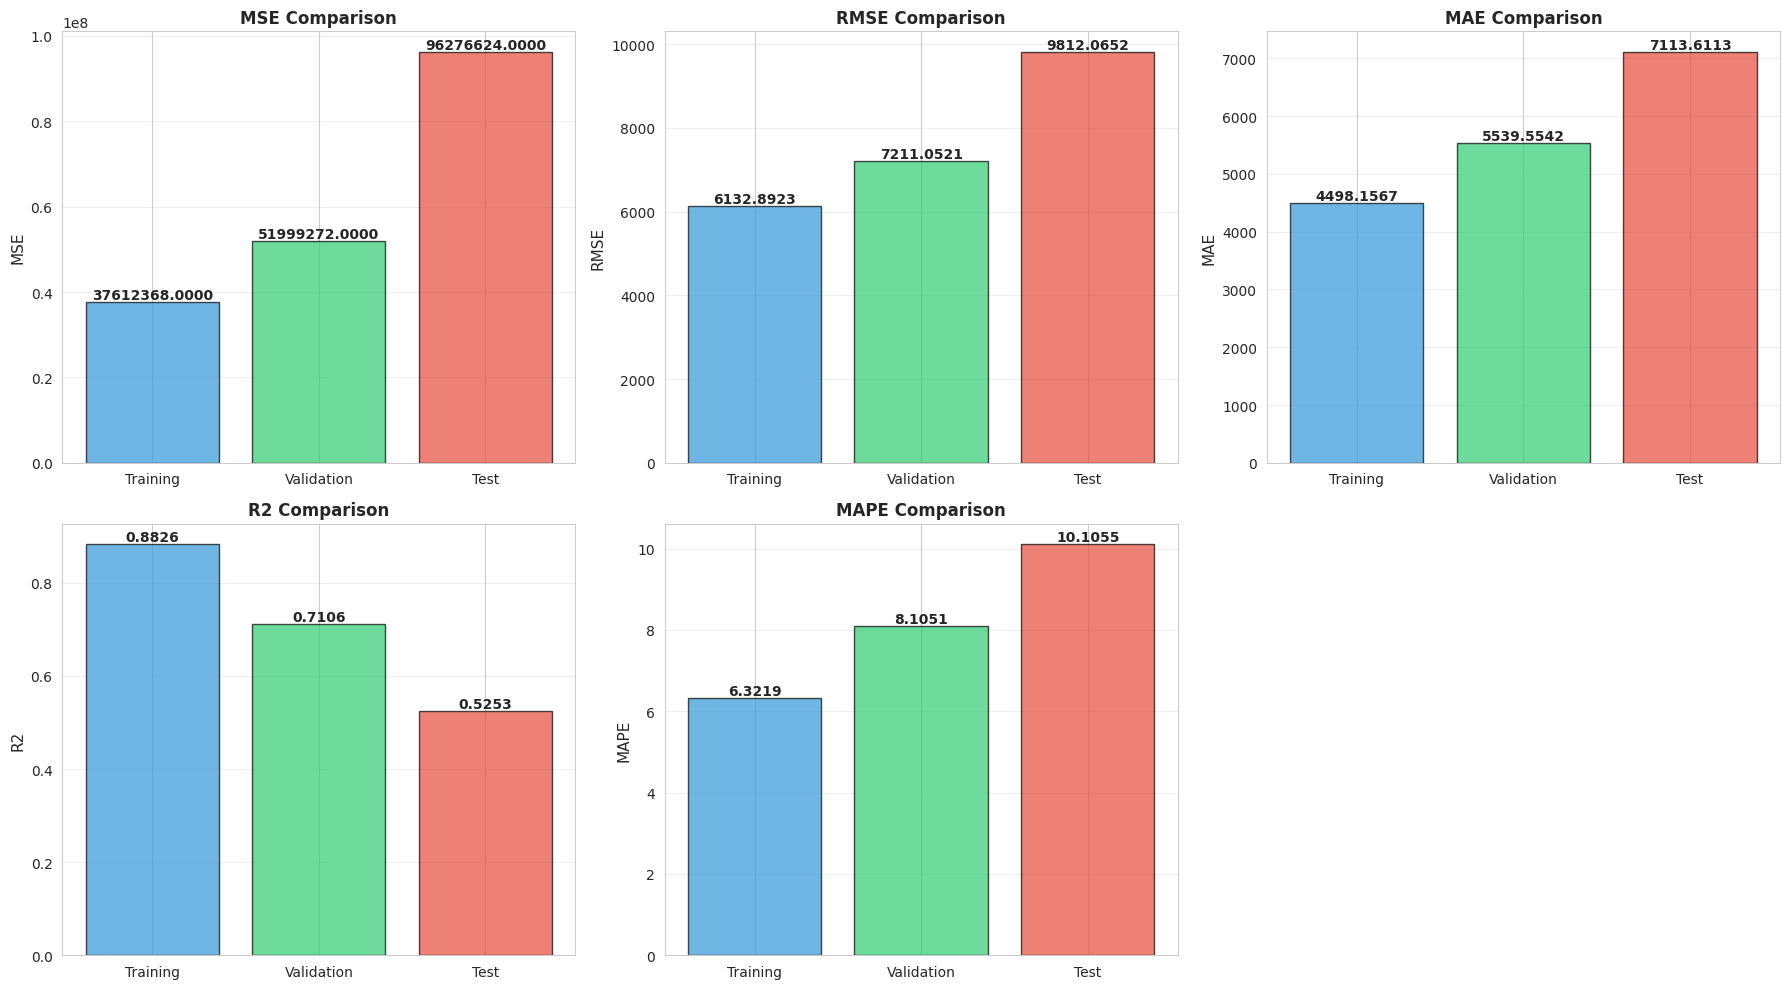

In [26]:
# Plot 4: Metrics Comparison
metrics_df = pd.DataFrame({
    'Training': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = ['MSE', 'RMSE', 'MAE', 'R2', 'MAPE']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    values = [train_metrics[metric], val_metrics[metric], test_metrics[metric]]
    bars = ax.bar(['Training', 'Validation', 'Test'], values, color=colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# Remove the last empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


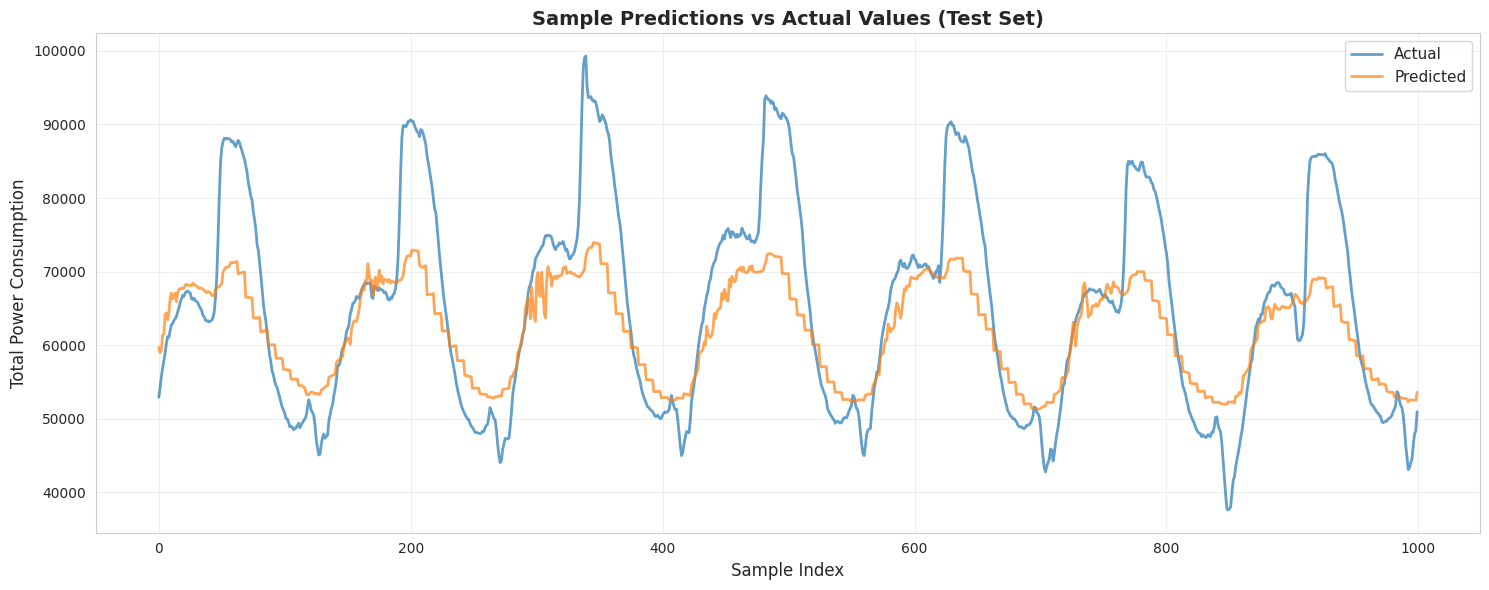

Showing 1000 samples from test set


In [27]:
# Plot 5: Sample predictions over time (showing first 1000 test samples)
sample_size = min(1000, len(test_actuals))
indices = np.arange(sample_size)

plt.figure(figsize=(15, 6))
plt.plot(indices, test_actuals[:sample_size], label='Actual', linewidth=2, alpha=0.7)
plt.plot(indices, test_preds[:sample_size], label='Predicted', linewidth=2, alpha=0.7)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Total Power Consumption', fontsize=12)
plt.title('Sample Predictions vs Actual Values (Test Set)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Showing {sample_size} samples from test set")


## 7. Save the Model


In [29]:
# Create output directory
output_dir = 'output/mlp'
os.makedirs(output_dir, exist_ok=True)

# Save the PyTorch model
model_path = os.path.join(output_dir, 'mlp_model.pth')
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

# Save the entire model (architecture + weights)
full_model_path = os.path.join(output_dir, 'mlp_model_complete.pth')
torch.save(model, full_model_path)
print(f"Complete model saved to: {full_model_path}")

# Save scalers using joblib
import joblib
scaler_X_path = os.path.join(output_dir, 'scaler_X.pkl')
scaler_y_path = os.path.join(output_dir, 'scaler_y.pkl')
joblib.dump(scaler_X, scaler_X_path)
joblib.dump(scaler_y, scaler_y_path)
print(f"Feature scaler saved to: {scaler_X_path}")
print(f"Target scaler saved to: {scaler_y_path}")

# Save feature names
feature_names_path = os.path.join(output_dir, 'feature_names.txt')
with open(feature_names_path, 'w') as f:
    f.write('\n'.join(feature_columns))
print(f"Feature names saved to: {feature_names_path}")

# Save model configuration
import json

# Convert numpy types to native Python types for JSON serialization
def convert_to_json_serializable(obj):
    """Convert numpy types to native Python types."""
    if isinstance(obj, dict):
        return {key: convert_to_json_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(item) for item in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

config = {
    'input_size': int(input_size),
    'hidden_sizes': hidden_sizes,
    'dropout_rate': float(dropout_rate),
    'feature_columns': feature_columns,
    'best_val_loss': float(best_val_loss),
    'test_metrics': convert_to_json_serializable(test_metrics)
}
config_path = os.path.join(output_dir, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f"Model configuration saved to: {config_path}")

print("\n" + "=" * 60)
print("All model artifacts saved successfully!")
print("=" * 60)


Model saved to: output/mlp/mlp_model.pth
Complete model saved to: output/mlp/mlp_model_complete.pth
Feature scaler saved to: output/mlp/scaler_X.pkl
Target scaler saved to: output/mlp/scaler_y.pkl
Feature names saved to: output/mlp/feature_names.txt
Model configuration saved to: output/mlp/model_config.json

All model artifacts saved successfully!
